In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import torchaudio
import torchaudio.transforms as T
import os
import glob
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

CUDA device: Tesla P100-PCIE-16GB


In [2]:

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(42)

INPUT_BASE = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
WORKING_BASE = '/kaggle/working'

STEMS_PATH = os.path.join(INPUT_BASE, 'genres_stems')
NOISE_PATH = os.path.join(INPUT_BASE, 'ESC-50-master/audio')
MASHUPS_PATH = os.path.join(INPUT_BASE, 'mashups')
TEST_CSV = os.path.join(INPUT_BASE, 'test.csv')

SYNTHETIC_OUTPUT_PATH = os.path.join(WORKING_BASE, 'synthetic_mashups/train')
FEATURES_OUTPUT_PATH = os.path.join(WORKING_BASE, 'features/train')

GENRES = ["blues", "classical", "country", "disco", "hiphop",
          "jazz", "metal", "pop", "reggae", "rock"]


In [3]:
def generate_synthetic_dataset(stems_dir, noise_dir, output_dir, samples_per_genre=500, target_sr=22050, duration=15):
    """Generates deterministic noisy mashups and saves them to /kaggle/working/."""
    
    genres = ["blues", "classical", "country", "disco", "hiphop",
              "jazz", "metal", "pop", "reggae", "rock"]
    target_length = target_sr * duration

    noise_files = glob.glob(os.path.join(noise_dir, '**', '*.wav'), recursive=True)
    print(f"Found {len(noise_files)} noise files")
    
    total_generated = 0
    
    for genre in genres:
        genre_out_dir = Path(output_dir) / genre
        genre_out_dir.mkdir(parents=True, exist_ok=True)
        
        song_folders = glob.glob(os.path.join(stems_dir, genre, '*'))
        if not song_folders:
            print(f"Warning: No songs found for genre {genre}")
            continue
        
        genre_count = 0
        for i in range(samples_per_genre):
            chosen_songs = random.sample(song_folders, 4)
            stems = []
            stem_types = ['drums.wav', 'vocals.wav', 'bass.wav', 'other.wav']
            
            for song, stem_type in zip(chosen_songs, stem_types):
                stem_path = os.path.join(song, stem_type)
                if os.path.exists(stem_path):
                    waveform, sr = torchaudio.load(stem_path)

                    if sr != target_sr:
                        resampler = torchaudio.transforms.Resample(sr, target_sr)
                        waveform = resampler(waveform)

                    if waveform.shape[0] > 1:
                        waveform = torch.mean(waveform, dim=0, keepdim=True)

                    if waveform.shape[1] > target_length:
                        waveform = waveform[:, :target_length]
                    elif waveform.shape[1] < target_length:
                        waveform = torch.nn.functional.pad(waveform, (0, target_length - waveform.shape[1]))
                    
                    stems.append(waveform)
            
            if len(stems) == 4:
                
                mashup = torch.stack(stems).sum(dim=0)
                mashup = mashup / (torch.max(torch.abs(mashup)) + 1e-8)

                noise_file = random.choice(noise_files)
                noise, noise_sr = torchaudio.load(noise_file)

                if noise_sr != target_sr:
                    resampler = torchaudio.transforms.Resample(noise_sr, target_sr)
                    noise = resampler(noise)

                if noise.shape[0] > 1:
                    noise = torch.mean(noise, dim=0, keepdim=True)
                
                if noise.shape[1] > target_length:
                    noise = noise[:, :target_length]

                start_idx = random.randint(0, target_length - noise.shape[1])
                intensity = random.uniform(0.1, 0.4)
                
                mashup[:, start_idx:start_idx + noise.shape[1]] += (noise * intensity)
                mashup = mashup / (torch.max(torch.abs(mashup)) + 1e-8)

                out_path = genre_out_dir / f"mashup_{i:03d}.wav"
                torchaudio.save(str(out_path), mashup, target_sr)
                genre_count += 1
                total_generated += 1
        
        print(f"{genre}: {genre_count} mashups generated")
    
    print(f"\n Total mashups generated: {total_generated}")
    return total_generated

total_files = generate_synthetic_dataset(
    stems_dir=STEMS_PATH,
    noise_dir=NOISE_PATH,
    output_dir=SYNTHETIC_OUTPUT_PATH,
    samples_per_genre=500,
    target_sr=22050,
    duration=15
)

Found 2000 noise files
blues: 500 mashups generated
classical: 500 mashups generated
country: 500 mashups generated
disco: 500 mashups generated
hiphop: 500 mashups generated
jazz: 500 mashups generated
metal: 500 mashups generated
pop: 500 mashups generated
reggae: 500 mashups generated
rock: 500 mashups generated

 Total mashups generated: 5000


In [4]:
def extract_and_save_features(input_dir, output_dir, target_sr=22050, n_fft=2048, hop_length=512, n_mels=128):
    """Converts audio to Mel-spectrograms in dB and saves as PyTorch tensors."""
    
    mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=target_sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels
    )
    amplitude_to_db = torchaudio.transforms.AmplitudeToDB()

    wav_files = glob.glob(os.path.join(input_dir, '**', '*.wav'), recursive=True)
    
    if not wav_files:
        print(f" Warning: No .wav files found in {input_dir}")
        return 0
    
    print(f"Found {len(wav_files)} .wav files to process")
    
    processed_count = 0
    for wav_path in wav_files:

        rel_path = os.path.relpath(wav_path, input_dir)
        out_path = Path(output_dir) / rel_path
        out_path = out_path.with_suffix('.pt')

        out_path.parent.mkdir(parents=True, exist_ok=True)

        waveform, sr = torchaudio.load(wav_path)
        mel_spec = mel_transform(waveform)
        mel_spec_db = amplitude_to_db(mel_spec)
        
        torch.save(mel_spec_db, out_path)
        processed_count += 1
    
    print(f"Successfully saved {processed_count} feature files to {output_dir}")
    return processed_count

features_count = extract_and_save_features(
    input_dir=SYNTHETIC_OUTPUT_PATH,
    output_dir=FEATURES_OUTPUT_PATH,
    target_sr=22050,
    n_fft=2048,
    hop_length=512,
    n_mels=128
)

Found 5000 .wav files to process
Successfully saved 5000 feature files to /kaggle/working/features/train


In [5]:
class PrecomputedFeatureDataset(Dataset):
    """Dataset class for loading pre-computed mel-spectrogram features."""
    
    def __init__(self, features_dir):
        self.files = glob.glob(os.path.join(features_dir, '**', '*.pt'), recursive=True)
        self.genres = sorted(['blues', 'classical', 'country', 'disco', 'hiphop', 
                              'jazz', 'metal', 'pop', 'reggae', 'rock'])
        self.genre_to_idx = {g: i for i, g in enumerate(self.genres)}
        self.idx_to_genre = {i: g for g, i in self.genre_to_idx.items()}
        
        print(f" Dataset loaded: {len(self.files)} samples")
        print(f"   Genres: {self.genres}")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = self.files[idx]
        genre = Path(file_path).parent.name
        label = self.genre_to_idx[genre]

        feature = torch.load(file_path)
        return feature, label

In [6]:
class CRNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.lstm = nn.LSTM(
            input_size=2048,
            hidden_size=64,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        
        self.fc = nn.Linear(64 * 2, num_classes)

    def forward(self, x):
        x = self.cnn(x)
        b, c, f, t = x.shape 
        x = x.permute(0, 3, 1, 2)
        x = x.reshape(b, t, c * f) 
        lstm_out, _ = self.lstm(x)
        pooled, _ = torch.max(lstm_out, dim=1) 
        logits = self.fc(pooled) 
        
        return logits

In [7]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for features, labels in dataloader:
        features = features.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc


def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for features, labels in dataloader:
            features = features.to(device)
            labels = labels.to(device)
            
            outputs = model(features)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    
    return epoch_loss, epoch_acc, macro_f1, all_preds, all_labels

In [8]:
# --- PREPARE DATA ---
full_dataset = PrecomputedFeatureDataset(FEATURES_OUTPUT_PATH)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

 Dataset loaded: 5000 samples
   Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Training samples: 4000
Validation samples: 1000
Total parameters: 1,102,666
Trainable parameters: 1,102,666


In [9]:
import wandb
import time
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
os.environ["WANDB_API_KEY"] = user_secrets.get_secret("WANDB_API_KEY")

wandb.login()

wandb.init(
    project="21f3000342-dl-genai-t12026",
    name=f"crnn_{time.strftime('%Y%m%d_%H%M%S')}",
    config={
        "architecture": "CRNN",
        "sample_rate": 22050,
        "duration": 15,
        "n_mels": 128,
        "n_fft": 2048,
        "hop_length": 512,
        "batch_size": 64,
        "epochs": 25,
        "learning_rate": 0.0005,
        "num_classes": 10,
        "samples_per_genre": 500,
        "total_params": total_params,
        "trainable_params": trainable_params
    }
)

wandb: Currently logged in as: 21f3000342 (21f3000342-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run qwggyjrz
wandb: Tracking run with wandb version 0.22.2
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260320_023830-qwggyjrz
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run crnn_20260320_023830
wandb: ⭐️ View project at https://wandb.ai/21f3000342-indian-institute-of-technology-madras/21f3000342-dl-genai-t12026
wandb: 🚀 View run at https://wandb.ai/21f3000342-indian-institute-of-technology-madras/21f3000342-dl-genai-t12026/runs/qwggyjrz


In [10]:
# --- TRAINING ---
num_epochs = 25
best_f1 = 0.0
best_model_state = None

metrics = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': []
}

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1, all_preds, all_labels = validate(model, val_loader, criterion, device)

    metrics['train_loss'].append(train_loss)
    metrics['train_acc'].append(train_acc)
    metrics['val_loss'].append(val_loss)
    metrics['val_acc'].append(val_acc)
    metrics['val_f1'].append(val_f1)

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1,
        "learning_rate": optimizer.param_groups[0]['lr']
    })

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_model_state = model.state_dict().copy()
    
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

model.load_state_dict(best_model_state)
print(f"\n Training complete! Best Validation F1: {best_f1:.4f}")

model_path = '/kaggle/working/crnn_model.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_f1': best_f1,
    'metrics': metrics,
}, model_path)

print(f" Model saved to {model_path}")
wandb.finish()

Epoch 1/25 | Train Loss: 1.8087 | Train Acc: 0.4303 | Val Loss: 1.5364 | Val Acc: 0.4930 | Val F1: 0.4372
Epoch 2/25 | Train Loss: 1.3382 | Train Acc: 0.6388 | Val Loss: 1.2519 | Val Acc: 0.6610 | Val F1: 0.6402
Epoch 3/25 | Train Loss: 1.1037 | Train Acc: 0.7180 | Val Loss: 1.0414 | Val Acc: 0.7390 | Val F1: 0.7292
Epoch 4/25 | Train Loss: 0.9136 | Train Acc: 0.7700 | Val Loss: 0.8739 | Val Acc: 0.7620 | Val F1: 0.7527
Epoch 5/25 | Train Loss: 0.7825 | Train Acc: 0.8123 | Val Loss: 0.7592 | Val Acc: 0.8130 | Val F1: 0.8053
Epoch 6/25 | Train Loss: 0.6763 | Train Acc: 0.8383 | Val Loss: 0.7372 | Val Acc: 0.7830 | Val F1: 0.7771
Epoch 7/25 | Train Loss: 0.6166 | Train Acc: 0.8565 | Val Loss: 0.6321 | Val Acc: 0.8330 | Val F1: 0.8253
Epoch 8/25 | Train Loss: 0.5097 | Train Acc: 0.8868 | Val Loss: 0.5598 | Val Acc: 0.8460 | Val F1: 0.8419
Epoch 9/25 | Train Loss: 0.4295 | Train Acc: 0.9077 | Val Loss: 0.4909 | Val Acc: 0.8680 | Val F1: 0.8653
Epoch 10/25 | Train Loss: 0.3834 | Train Acc: 

wandb: updating run metadata


Epoch 25/25 | Train Loss: 0.0446 | Train Acc: 0.9992 | Val Loss: 0.2247 | Val Acc: 0.9290 | Val F1: 0.9266

 Training complete! Best Validation F1: 0.9268
 Model saved to /kaggle/working/crnn_model.pth


wandb: uploading history steps 24-24, summary, console lines 24-27
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
wandb: learning_rate ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     train_acc ▁▄▅▅▆▆▆▇▇▇▇▇▇████████████
wandb:    train_loss █▆▅▄▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
wandb:       val_acc ▁▄▅▅▆▆▆▇▇▇▇▇▇▇███████████
wandb:        val_f1 ▁▄▅▆▆▆▇▇▇▇▇▇▇████████████
wandb:      val_loss █▆▅▄▄▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
wandb: 
wandb: Run summary:
wandb:         epoch 25
wandb: learning_rate 0.0005
wandb:     train_acc 0.99925
wandb:    train_loss 0.04459
wandb:       val_acc 0.929
wandb:        val_f1 0.92657
wandb:      val_loss 0.22474
wandb: 
wandb: 🚀 View run crnn_20260320_023830 at: https://wandb.ai/21f3000342-indian-institute-of-technology-madras/21f3000342-dl-genai-t12026/runs/qwggyjrz
wandb: ⭐️ View project at: https://wandb.ai/21f3000342-indian-institute-of-technology-madras/21f3000342-dl-genai-t12026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 othe


----- CLASSIFICATION REPORT -----
              precision    recall  f1-score   support

       blues     0.9333    0.9515    0.9423       103
   classical     0.9917    0.9917    0.9917       121
     country     0.9444    0.9043    0.9239        94
       disco     0.8962    0.9223    0.9091       103
      hiphop     0.8704    0.9495    0.9082        99
        jazz     0.9811    0.9630    0.9720       108
       metal     0.9302    0.9877    0.9581        81
         pop     0.9143    0.9412    0.9275       102
      reggae     0.8854    0.8763    0.8808        97
        rock     0.9351    0.7826    0.8521        92

    accuracy                         0.9290      1000
   macro avg     0.9282    0.9270    0.9266      1000
weighted avg     0.9299    0.9290    0.9285      1000



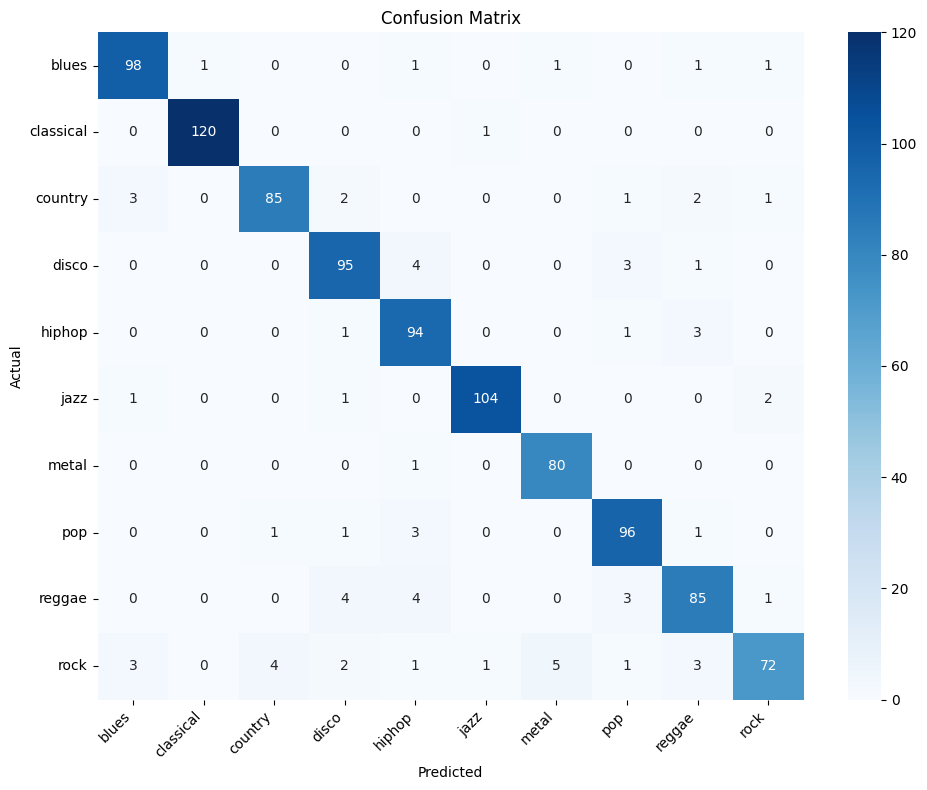

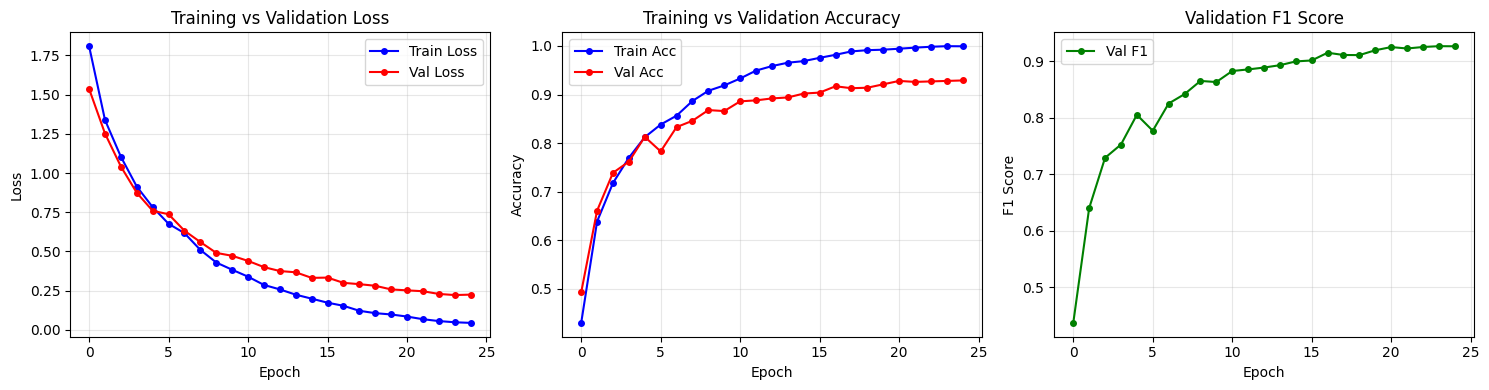

In [11]:
# --- VISUALIZATION ---
model.eval()
all_preds = []
all_labels_list = []

with torch.no_grad():
    for features, labels in val_loader:
        features = features.to(device)
        outputs = model(features)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels_list.extend(labels.numpy())

print("\n----- CLASSIFICATION REPORT -----")
print(classification_report(all_labels_list, all_preds, target_names=GENRES, digits=4))

# Confusion Matrix
cm = confusion_matrix(all_labels_list, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GENRES, yticklabels=GENRES)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Training Curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss plot
axes[0].plot(metrics['train_loss'], 'b-o', label='Train Loss', markersize=4)
axes[0].plot(metrics['val_loss'], 'r-o', label='Val Loss', markersize=4)
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(metrics['train_acc'], 'b-o', label='Train Acc', markersize=4)
axes[1].plot(metrics['val_acc'], 'r-o', label='Val Acc', markersize=4)
axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1 Score plot
axes[2].plot(metrics['val_f1'], 'g-o', label='Val F1', markersize=4)
axes[2].set_title('Validation F1 Score')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
from tqdm import tqdm
import gc

class TestAudioProcessor:
    def __init__(self, sample_rate=22050, n_mels=128, n_fft=2048, hop_length=512, duration=15):
        self.sample_rate = sample_rate
        self.duration = duration
        self.target_length = sample_rate * duration
        
        self.mel_transform = T.MelSpectrogram(
            sample_rate=sample_rate,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels
        )
        self.db_transform = T.AmplitudeToDB()
    
    def process(self, path):
        try:
            waveform, sr = torchaudio.load(path)
            
            if sr != self.sample_rate:
                resampler = T.Resample(sr, self.sample_rate)
                waveform = resampler(waveform)
            
            if waveform.shape[0] > 1:
                waveform = torch.mean(waveform, dim=0, keepdim=True)
            
            if waveform.shape[1] < self.target_length:
                padding = self.target_length - waveform.shape[1]
                waveform = torch.nn.functional.pad(waveform, (0, padding))
            else:
                waveform = waveform[:, :self.target_length]
            
            mel_spec = self.mel_transform(waveform)
            mel_spec_db = self.db_transform(mel_spec)
            return mel_spec_db
        except:
            return None


def prepare_test_data(processor):
    test_df = pd.read_csv(TEST_CSV)
    
    all_spectrograms = []
    test_ids = []
    
    for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Processing test"):
        test_id = row['id']
        audio_file = f"song{str(test_id).zfill(4)}.wav"
        audio_path = os.path.join(MASHUPS_PATH, audio_file)
        
        if not os.path.exists(audio_path):
            continue
        
        mel_spec = processor.process(audio_path)
        
        if mel_spec is not None:
            all_spectrograms.append(mel_spec.squeeze(0))
            test_ids.append(test_id)
        
        if idx % 500 == 0:
            gc.collect()
    
    spectrograms = torch.stack(all_spectrograms)
    return spectrograms, test_ids


class TestDataset(Dataset):
    def __init__(self, spectrograms):
        self.spectrograms = spectrograms
    
    def __len__(self):
        return len(self.spectrograms)
    
    def __getitem__(self, idx):
        return self.spectrograms[idx].unsqueeze(0)


def predict(model, dataloader, device):
    model.eval()
    all_preds = []
    
    with torch.no_grad():
        for spectrograms in dataloader:
            if isinstance(spectrograms, tuple):
                spectrograms = spectrograms[0]
            
            spectrograms = spectrograms.to(device)
            outputs = model(spectrograms)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
    
    return all_preds

In [13]:
processor = TestAudioProcessor(
    sample_rate=22050,
    n_mels=128,
    n_fft=2048,
    hop_length=512,
    duration=15
)

test_spectrograms, test_ids = prepare_test_data(processor)

test_dataset = TestDataset(test_spectrograms)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

idx_to_genre = {i: g for i, g in enumerate(GENRES)}

predictions = predict(model, test_loader, device)
pred_labels = [idx_to_genre[pred] for pred in predictions]

submission = pd.DataFrame({'id': test_ids, 'genre': pred_labels})
submission.to_csv('submission.csv', index=False)

print(f"\nPrediction distribution:")
print(submission['genre'].value_counts().sort_index())

Processing test: 100%|██████████| 3020/3020 [01:58<00:00, 25.49it/s]



Prediction distribution:
genre
blues        182
classical    142
country       84
disco        253
hiphop       587
jazz         273
metal        162
pop          341
reggae       400
rock         596
Name: count, dtype: int64
